# EdgeRunner - EDA y Baseline en un solo notebook

Este notebook junta en una sola historia lo que hemos ido haciendo en el proyecto EdgeRunner.

La idea es que se pueda leer como una entrega o una defensa oral:

1. primero explico el problema;
2. luego explico los datos;
3. despues justifico el target;
4. despues muestro las decisiones de EDA;
5. al final muestro los baselines, el backtest conservador y la conclusion.

Importante: este notebook **no recalcula las ejecuciones largas**. Algunas tardan horas. Aqui cargo resultados ya generados y los explico de forma ordenada.

## 0. Resumen muy corto

El proyecto intenta responder esta pregunta:

> Podemos detectar momentos muy concretos donde comprar un token BTC de Polymarket tenga ventaja a muy corto plazo?

No estamos haciendo un bot todavia. Estamos validando si hay senal predictiva offline.

La conclusion actual es:

- si hay senal offline;
- la mejor combinacion viene de Polymarket + perp + tiempo de ventana;
- el target principal es movimiento a `16s` medido en ticks;
- `full_v0` es el baseline general;
- `full_no_micro_highconv` es la politica conservadora candidata;
- v0.2 ya mete coste visible, buffers y cooldowns simples;
- todavia falta ejecucion realista de fill/slippage antes de pensar en bot.

In [1]:
# Imports y rutas basicas.
# La idea es que el notebook sea ligero: leer CSV/JSON ya generados y mostrar tablas.

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Detectar raiz del proyecto aunque el notebook se abra desde /notebooks.
PROJECT = Path.cwd()
if not (PROJECT / 'docs').exists() and (PROJECT.parent / 'docs').exists():
    PROJECT = PROJECT.parent

DOCS = PROJECT / 'docs'
DATA = PROJECT / 'data'
FULL_RESULTS = DATA / 'experiments' / 'baseline_v0_full_core_robustness' / 'results'
V01_RESULTS = DATA / 'experiments' / 'baseline_v01_threshold_bootstrap'
V02_RESULTS = DATA / 'experiments' / 'baseline_v02_conservative_backtest'
SUPPORT = DATA / 'experiments' / 'unified_notebook_support'

print('PROJECT =', PROJECT)
print('FULL_RESULTS exists =', FULL_RESULTS.exists())
print('V01_RESULTS exists =', V01_RESULTS.exists())
print('V02_RESULTS exists =', V02_RESULTS.exists())
print('SUPPORT exists =', SUPPORT.exists())

PROJECT = C:\Users\ftpx\Desktop\Recolector\edgerunner
FULL_RESULTS exists = True
V01_RESULTS exists = True
V02_RESULTS exists = True
SUPPORT exists = True


In [2]:
# Helpers peque?os para cargar resultados sin repetir codigo.

def read_csv(path, **kwargs):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'No existe: {path}')
    return pd.read_csv(path, **kwargs)


def read_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'No existe: {path}')
    return json.loads(path.read_text(encoding='utf-8'))


def pct_cols(df, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = out[col].round(2)
    return out


## 1. Que datos usamos

La fuente de verdad es la SQLite oficial:

`D:\polymarket_btc_probe_official_v1\polymarket_week.sqlite3`

No usamos JSONL compactados como fuente principal y no reabrimos el recolector.

Tablas importantes:

| Tabla | Para que sirve |
|---|---|
| `cross_venue_features` | fila principal con Polymarket + referencias externas |
| `polymarket_grid_rows` | precios/estado del token en cada instante |
| `market_metadata` | tick size, ventanas, temporalidad, fees |
| `collection_sessions` | sesiones y tier del dataset |
| `collection_session_telemetry` | calidad/cobertura de sesiones |
| `session_market_tradability` | estado operativo del mercado |
| `predictor_labels` | labels H8 materializados, usados como auditoria/benchmark |

Para no recalcular durante horas, la ejecucion full-core genero una cache Parquet experimental, pero SQLite sigue siendo la fuente oficial.

In [3]:
# Numeros principales del corpus y de la cache experimental.
full_summary = read_json(FULL_RESULTS / 'summary.json')
v01_summary = read_json(V01_RESULTS / 'summary.json')

corpus_overview = pd.DataFrame([
    {'metrica': 'sesiones importadas', 'valor': '2,604', 'comentario': 'corpus oficial ya capturado'},
    {'metrica': 'sesiones core', 'valor': '2,590', 'comentario': 'baseline limpio por defecto'},
    {'metrica': 'filas cross_venue_features', 'valor': '2,499,840', 'comentario': 'tabla base original'},
    {'metrica': 'filas predictor_labels', 'valor': '2,433,124', 'comentario': 'labels H8 materializados'},
    {'metrica': 'filas H16 limpias usadas', 'valor': f"{full_summary['rows']:,}", 'comentario': 'cache experimental full-core'},
    {'metrica': 'market-frames completos', 'valor': f"{full_summary['complete_market_frames']:,}", 'comentario': 'pares UP/DOWN completos'},
    {'metrica': 'filas test v0.1', 'valor': f"{v01_summary['test_rows']:,}", 'comentario': 'test terminal'},
])
display(corpus_overview)


,metrica,valor,comentario
0,sesiones importadas,"2,604",corpus oficial ya capturado
1,sesiones core,"2,590",baseline limpio por defecto
2,filas cross_venue_features,"2,499,840",tabla base original
3,filas predictor_labels,"2,433,124",labels H8 materializados
4,filas H16 limpias usadas,"2,345,284",cache experimental full-core
5,market-frames completos,"1,172,642",pares UP/DOWN completos
6,filas test v0.1,"436,712",test terminal


### 1.1 Diccionario sencillo del dataset

Para entender el dataset, no hace falta memorizar todas las columnas. Lo importante es separar:

- **claves**: identifican la fila;
- **features causales**: lo que se sabe en el momento `t`;
- **labels/targets**: lo que pasa en el futuro, solo para entrenar/evaluar;
- **masks/calidad**: indican si el dato o el mercado esta limpio.

La tabla siguiente es una version corta, pensada para estudiar y explicarla.

In [4]:
feature_dictionary = read_csv(SUPPORT / 'dataset_feature_dictionary.csv')
display(feature_dictionary)


,bloque,columna,explicacion
0,Claves,session_id + token_id + time_index_ns,Identifican una observacion de un token en un ...
1,Claves,session_id + condition_id + time_index_ns,Identifican un market-frame completo; aqui se ...
2,Polymarket,polymarket_mid,Precio medio visible entre mejor bid y mejor ask.
3,Polymarket,microprice,Precio ajustado por presion del libro; si se s...
4,Polymarket,spread / spread_ticks,Coste visible de cruzar el libro; spreads alto...
5,Polymarket,visible_entry_cost_ticks,Aproximacion de coste de entrada en ticks: med...
6,Polymarket,mid_delta_ticks_2s/8s,Movimiento pasado reciente del token; es causa...
7,Externo,perp_mid_return_bps_2s/8s_oriented,Movimiento reciente del perp de BTC orientado ...
8,Externo,external_mid_return_bps_2s/8s_oriented,Movimiento reciente spot orientado; aporta men...
9,Tiempo,seconds_from_window_start / seconds_to_window_end,Donde estamos dentro de la ventana de mercado.


### 1.2 Que tenemos realmente del orderbook

En v0 no usamos un encoder de libro completo. Usamos **resumenes del libro**:

- `best_bid` y `best_ask` se resumen en `mid` y `spread`;
- `microprice` resume la presion entre bid/ask;
- `trade_imbalance` resume compras/ventas recientes;
- `visible_entry_cost_ticks` aproxima el coste de entrar cruzando spread.

Para visualizar, si podemos leer `row_json` de SQLite y ensenar niveles top-of-book. Pero esos niveles se usan aqui como **explicacion visual**, no como feature fuerte del baseline.

## 2. Target: que estamos intentando predecir

El target principal es:

```text
delta_ticks_16s = (mid[t+16s] - mid[t]) / tick_size
```

Es decir: cu?nto cambia el precio del token durante los pr?ximos `16 segundos`, medido en ticks.

Lo convertimos en 3 clases:

| Clase | Regla |
|---|---|
| `up` | sube al menos `1 tick` |
| `down` | baja al menos `1 tick` |
| `flat` | se queda entre `-1` y `+1 tick` |

Elegimos `16s` porque a `8s` habia demasiado `flat`. `16s` sigue siendo corto plazo, pero da m?s movimiento para aprender algo.

,target_3c_16s_1tick,pct
0,flat,47.3387
1,up,26.4383
2,down,26.2230


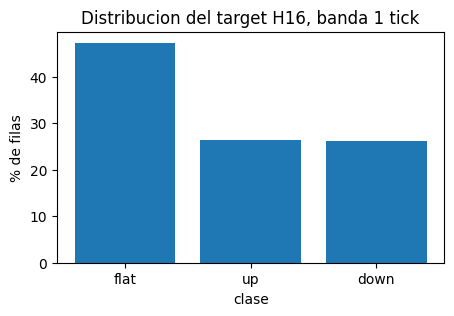

In [5]:
target_dist = read_csv(FULL_RESULTS / 'target_distribution.csv')
display(target_dist)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(target_dist['target_3c_16s_1tick'], target_dist['pct'])
ax.set_title('Distribucion del target H16, banda 1 tick')
ax.set_ylabel('% de filas')
ax.set_xlabel('clase')
plt.show()


## 3. Splits: como evitamos hacer trampas sin querer

No usamos un split aleatorio como metrica principal porque en series temporales puede mezclar pasado y futuro.

La idea principal es:

- entrenar con dias anteriores;
- validar con dias posteriores;
- dejar un test terminal al final;
- purgar mercados repetidos por `condition_id`.

Esto es importante porque si el mismo mercado aparece en train y test, el resultado puede parecer mejor de lo que es.

In [6]:
qa_split = read_csv(FULL_RESULTS / 'qa_split_rows.csv')
purge_audit = read_csv(FULL_RESULTS / 'purge_audit.csv')

display(qa_split.pivot(index='terminal_split', columns='temporality', values='rows').fillna(0).astype(int))
display(purge_audit)


temporality,15m,1h,5m
terminal_split,,,
test_terminal,145452,145532,145728
train_initial,534794,524108,535810
validation_initial,104474,104670,104716


,fold,train_start,train_end,val_start,val_end,train_rows_before,train_rows_after_purge,val_rows,purged_rows,condition_overlap,test_condition_overlap_after_purge
0,F1,2026-05-11,2026-05-14,2026-05-15,2026-05-16,568040,567308,362442,732,2,NaN
1,F2,2026-05-11,2026-05-16,2026-05-17,2026-05-18,930482,930482,343116,0,0,NaN
2,F3,2026-05-11,2026-05-18,2026-05-19,2026-05-20,1273598,1272990,321114,608,2,NaN
3,F4,2026-05-11,2026-05-20,2026-05-21,2026-05-22,1594712,1594712,313860,0,0,NaN
4,FINAL,2026-05-11,2026-05-20,2026-05-21,2026-05-22,1594712,1594712,313860,0,0,0.0000


## 4. Features: que informacion le damos al modelo

No empezamos con todo. Usamos bloques simples y defendibles.

| Bloque | Ejemplos | Por que importa |
|---|---|---|
| Polymarket | mid, spread, coste visible, cambios recientes | mide el estado local del token |
| Perp / spot | retornos orientados 2s/8s | BTC externo puede adelantarse al token |
| Tiempo | segundos desde inicio, segundos a cierre, temporalidad | el comportamiento cambia dentro de la ventana |
| Acuerdos | PM + perp apuntan juntos | captura interacciones simples |

Dejamos fuera de v0:

- Coinbase;
- depth de Binance;
- Deribit;
- sidecars opcionales;
- contexto de holders/OI no auditado como `as-of`;
- modelos complejos.

## 5. Correlaciones: que variables se relacionan con el futuro

Antes de entrenar modelos, conviene mirar correlaciones simples.

Aqui usamos una muestra determinista de `200k` filas de la cache full-core. No usamos todas las filas porque Spearman ordena/rankea datos y seria mas pesado para una libreta de presentacion.

Importante: una correlacion no demuestra causalidad ni garantiza dinero. Solo responde:

> cuando esta feature sube, el movimiento futuro en ticks tiende a subir o bajar?

Usamos sobre todo **Spearman**, porque es mas robusta si la relacion no es lineal.

,block,feature,n,spearman,pearson
0,Polymarket microestructura,microprice_gap_ticks_clipped,200000,0.1993,0.1102
1,Polymarket microestructura,polymarket_microprice_gap_bps,200000,0.1866,0.0462
2,Referencias externas,perp_mid_return_bps_2s_oriented,198642,0.1416,0.1218
3,Referencias externas,external_mid_return_bps_2s_oriented,198642,0.1337,0.1071
4,Referencias externas,perp_mid_return_bps_8s_oriented,194504,0.1089,0.0857
5,Referencias externas,external_mid_return_bps_8s_oriented,194504,0.0961,0.0735
6,Polymarket microestructura,mid_delta_ticks_2s,198701,0.0734,0.0432
7,Polymarket microestructura,polymarket_mid,200000,0.0691,-0.0004
8,Referencias externas,perp_mark_price_return_bps_2s_oriented,198642,0.0560,0.0370
9,Polymarket microestructura,mid_delta_ticks_8s,194736,0.0553,0.0141


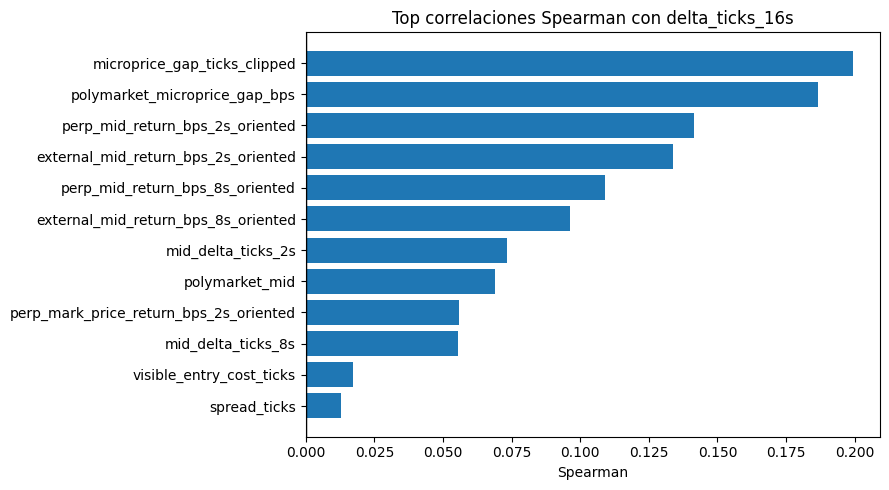

In [7]:
corr = read_csv(SUPPORT / 'feature_correlations.csv')
overall_corr = corr[corr['group_type'].eq('all')].sort_values('abs_spearman', ascending=False)
display(overall_corr[['block','feature','n','spearman','pearson']].head(15).round(4))

plot_corr = overall_corr.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_corr['feature'], plot_corr['spearman'])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top correlaciones Spearman con delta_ticks_16s')
ax.set_xlabel('Spearman')
plt.tight_layout()
plt.show()


### Lectura rapida de las correlaciones

Lo que deberiamos ver si todo tiene sentido:

- `microprice_gap` de Polymarket aparece arriba;
- retornos orientados del perp aparecen arriba;
- spot ayuda, pero normalmente menos que perp;
- deltas recientes de PM tambien aportan;
- las correlaciones son moderadas, no enormes. Esto es normal en microestructura: buscamos peque?as ventajas repetibles, no una senal perfecta.

group,15m,1h,5m
feature,,,
microprice_gap_ticks_clipped,0.1951,0.2368,0.1699
polymarket_microprice_gap_bps,0.1816,0.2131,0.1674
perp_mid_return_bps_2s_oriented,0.1506,0.1897,0.0896
external_mid_return_bps_2s_oriented,0.1371,0.1868,0.0825
perp_mid_return_bps_8s_oriented,0.0946,0.1788,0.0616
external_mid_return_bps_8s_oriented,0.0789,0.1689,0.0492
mid_delta_ticks_2s,0.0929,0.0770,0.0452
polymarket_mid,0.0701,0.0745,0.0422


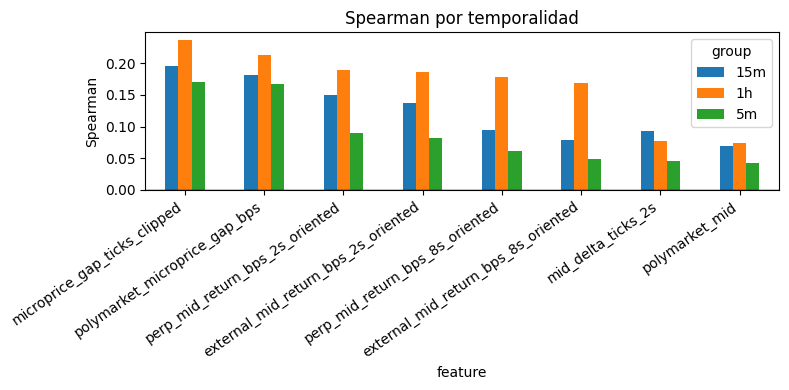

In [8]:
temp_corr = corr[corr['group_type'].eq('temporality')].copy()
top_features = overall_corr.head(8)['feature'].tolist()
pivot = temp_corr[temp_corr['feature'].isin(top_features)].pivot(index='feature', columns='group', values='spearman')
display(pivot.loc[top_features].round(4))

fig, ax = plt.subplots(figsize=(8, 4))
pivot.loc[top_features].plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Spearman por temporalidad')
ax.set_ylabel('Spearman')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 6. Deciles: ver la senal sin asumir linealidad

La correlacion resume todo en un numero. Para entenderlo mejor, miro deciles: divido una feature en 10 grupos y veo el movimiento futuro medio.

Esto es mas facil de explicar: si los deciles altos tienen mejor `delta_ticks_16s`, la feature tiene direccion util.

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ftpx\AppData\Local\Temp\ipykernel_28196\1871447663.py:8: SyntaxWarning: invalid escape sequence '\d'
  part['decile_num'] = part['decile'].str.extract('(\d+)').astype(int)


,feature,decile,n,feature_min,feature_max,delta_mean,delta_median,up_pct,flat_pct,down_pct
0,microprice_gap_ticks_clipped,d1,20000,-5.0000,-0.4403,-0.9607,0.0000,17.1300,41.9800,40.8900
1,microprice_gap_ticks_clipped,d2,20000,-0.4403,-0.3510,-0.7387,0.0000,18.4650,45.7400,35.7950
2,microprice_gap_ticks_clipped,d3,20000,-0.3510,-0.2436,-0.3928,0.0000,20.4800,48.4300,31.0900
3,microprice_gap_ticks_clipped,d4,20000,-0.2436,-0.1201,-0.2530,0.0000,22.3050,49.1450,28.5500
4,microprice_gap_ticks_clipped,d5,20000,-0.1201,0.0031,-0.0777,0.0000,22.9850,51.9350,25.0800
5,microprice_gap_ticks_clipped,d6,20000,0.0031,0.1257,0.0960,0.0000,25.1650,51.9650,22.8700
6,microprice_gap_ticks_clipped,d7,20000,0.1257,0.2484,0.2908,0.0000,29.1600,48.9500,21.8900
7,microprice_gap_ticks_clipped,d8,20000,0.2484,0.3547,0.5130,0.0000,31.6900,48.5800,19.7300
8,microprice_gap_ticks_clipped,d9,20000,0.3547,0.4419,0.6801,0.0000,36.4950,44.7900,18.7150
9,microprice_gap_ticks_clipped,d10,20000,0.4419,5.0000,0.9267,0.0000,41.5900,41.4050,17.0050


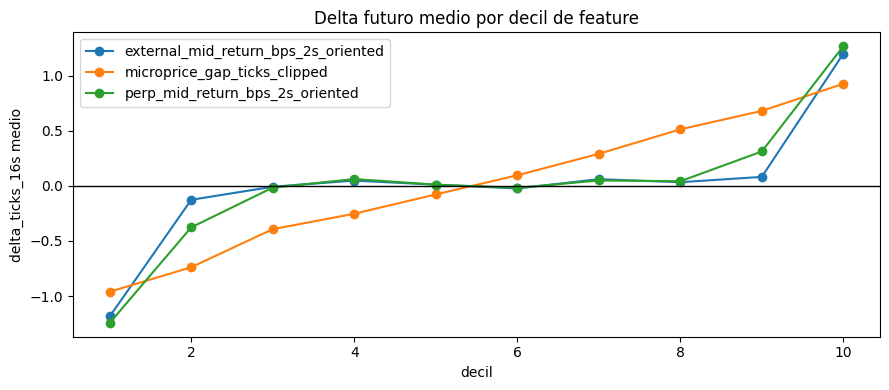

In [9]:
feature_deciles = read_csv(SUPPORT / 'feature_deciles.csv')
interesting = ['microprice_gap_ticks_clipped', 'perp_mid_return_bps_2s_oriented', 'external_mid_return_bps_2s_oriented']
display(feature_deciles[feature_deciles['feature'].isin(interesting)].round(4).head(30))

fig, ax = plt.subplots(figsize=(9, 4))
for feature, part in feature_deciles[feature_deciles['feature'].isin(interesting)].groupby('feature'):
    part = part.copy()
    part['decile_num'] = part['decile'].str.extract('(\d+)').astype(int)
    ax.plot(part['decile_num'], part['delta_mean'], marker='o', label=feature)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Delta futuro medio por decil de feature')
ax.set_xlabel('decil')
ax.set_ylabel('delta_ticks_16s medio')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Visualizacion del orderbook / microestructura

Aqui ense?o un ejemplo real de una accion marcada por el modelo.

Hay dos visualizaciones:

1. **serie temporal** alrededor de la accion: mid, microprice, bid/ask proxy y spread;
2. **snapshot de niveles top 10** desde `row_json` de SQLite para ver el libro visible en ese instante.

Esto ayuda a entender que el modelo no trabaja con una abstraccion misteriosa: mira precios, spread, presion y referencias externas.

In [10]:
support_summary = read_json(SUPPORT / 'summary.json')
sample_action = read_json(SUPPORT / 'sample_action.json')
print('Accion de ejemplo:')
print(json.dumps({
    'session_id': support_summary['sample_action']['session_id'],
    'time_index_ns': support_summary['sample_action']['time_index_ns'],
    'score_buy': round(support_summary['sample_action']['score_buy'], 4),
    'target': support_summary['sample_action']['target'],
    'delta_ticks_16s': support_summary['sample_action']['delta_ticks_16s'],
}, indent=2))


Accion de ejemplo:
{
  "session_id": 2371,
  "time_index_ns": 1779623750370470900,
  "score_buy": 0.7221,
  "target": "up",
  "delta_ticks_16s": 13.0
}


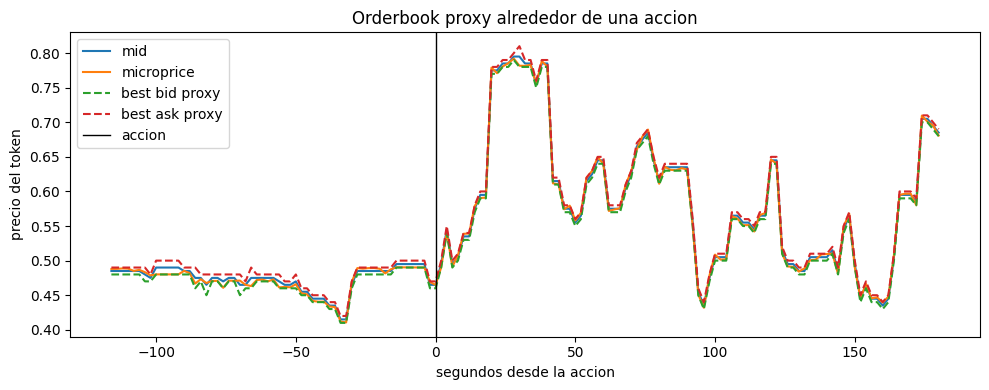

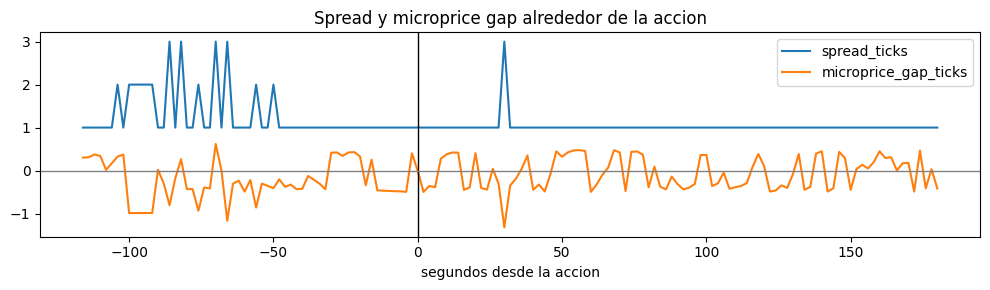

In [11]:
ob = read_csv(SUPPORT / 'sample_orderbook_proxy_timeseries.csv')
action_token = ob[ob['is_action_token'].eq(True)].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(action_token['seconds_from_action'], action_token['polymarket_mid'], label='mid')
ax.plot(action_token['seconds_from_action'], action_token['microprice'], label='microprice')
ax.plot(action_token['seconds_from_action'], action_token['best_bid_proxy'], linestyle='--', label='best bid proxy')
ax.plot(action_token['seconds_from_action'], action_token['best_ask_proxy'], linestyle='--', label='best ask proxy')
ax.axvline(0, color='black', linewidth=1, label='accion')
ax.set_title('Orderbook proxy alrededor de una accion')
ax.set_xlabel('segundos desde la accion')
ax.set_ylabel('precio del token')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(action_token['seconds_from_action'], action_token['spread_ticks'], label='spread_ticks')
ax.plot(action_token['seconds_from_action'], action_token['microprice_gap_ticks'], label='microprice_gap_ticks')
ax.axvline(0, color='black', linewidth=1)
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Spread y microprice gap alrededor de la accion')
ax.set_xlabel('segundos desde la accion')
ax.legend()
plt.tight_layout()
plt.show()


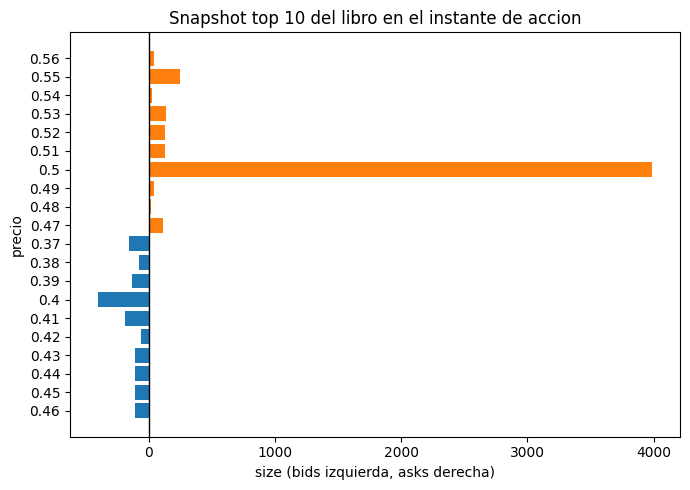

,side,rank,price,size,best_bid,best_ask,mid,microprice,book_imbalance_top_10
0,bid,1,0.4600,108.7800,0.4600,0.4700,0.4650,0.4649,-0.5423
1,bid,2,0.4500,110.3000,0.4600,0.4700,0.4650,0.4649,-0.5423
2,bid,3,0.4400,110.3000,0.4600,0.4700,0.4650,0.4649,-0.5423
3,bid,4,0.4300,109.3000,0.4600,0.4700,0.4650,0.4649,-0.5423
4,bid,5,0.4200,63.3000,0.4600,0.4700,0.4650,0.4649,-0.5423
5,bid,6,0.4100,184.4000,0.4600,0.4700,0.4650,0.4649,-0.5423
6,bid,7,0.4000,402.3900,0.4600,0.4700,0.4650,0.4649,-0.5423
7,bid,8,0.3900,128.4900,0.4600,0.4700,0.4650,0.4649,-0.5423
8,bid,9,0.3800,73.0000,0.4600,0.4700,0.4650,0.4649,-0.5423
9,bid,10,0.3700,158.1600,0.4600,0.4700,0.4650,0.4649,-0.5423


In [12]:
levels = read_csv(SUPPORT / 'sample_orderbook_levels.csv')
action_levels = levels[levels['is_action_token'].eq(True)].copy()
# Para verlo como libro: bids a la izquierda, asks a la derecha.
action_levels['signed_size'] = np.where(action_levels['side'].eq('bid'), -action_levels['size'], action_levels['size'])

fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(action_levels['side'].eq('bid'), 'tab:blue', 'tab:orange')
ax.barh(action_levels['price'].astype(str), action_levels['signed_size'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Snapshot top 10 del libro en el instante de accion')
ax.set_xlabel('size (bids izquierda, asks derecha)')
ax.set_ylabel('precio')
plt.tight_layout()
plt.show()

display(action_levels[['side','rank','price','size','best_bid','best_ask','mid','microprice','book_imbalance_top_10']].head(20))


### Lectura del ejemplo de orderbook

Lo importante no es este caso concreto, sino entender las variables:

- si el `microprice` se separa del `mid`, hay presion en un lado del libro;
- el `spread` marca el coste minimo de entrada;
- los niveles top 10 ense?an cuanta liquidez visible hay cerca del precio;
- en v0 usamos resumenes de esto, no un encoder profundo del libro.

Esto es exactamente por lo que todavia no pasamos a bot: predecir movimiento no es lo mismo que garantizar ejecucion real.

## 8. Decisiones principales de EDA

Esta tabla es mi mapa mental de lo que fuimos decidiendo. No es un resultado de modelo, es la parte de entender los datos.

In [13]:
eda_decisions = pd.DataFrame([
    {'paso': 'EDA 01-04', 'decision': 'trabajar por fases', 'por_que': 'primero entender datos y labels antes de automatizar'},
    {'paso': 'EDA 05', 'decision': 'target principal H16 con banda 1 tick', 'por_que': 'menos flat que H8 y sigue siendo corto plazo'},
    {'paso': 'EDA 06', 'decision': 'microprice gap PM entra en shortlist', 'por_que': 'tiene relacion con movimiento futuro'},
    {'paso': 'EDA 07', 'decision': 'retornos spot/perp orientados entran en shortlist', 'por_que': 'perp/spot aportan senal externa'},
    {'paso': 'EDA 08/08b', 'decision': 'PM + perp alineados es prometedor', 'por_que': 'cuando apuntan juntos mejora la probabilidad'},
    {'paso': 'EDA 09', 'decision': 'evaluar por market-frame', 'por_que': 'UP y DOWN son complementarios, no dos oportunidades separadas'},
    {'paso': 'Baseline v0', 'decision': 'usar HGB peque?o + logistica como baseline', 'por_que': 'simple, interpretable y suficiente para tabular'},
    {'paso': 'v0.1', 'decision': 'threshold 0.55 elegido por folds', 'por_que': 'evita elegir umbral mirando test'},
])
display(eda_decisions)


,paso,decision,por_que
0,EDA 01-04,trabajar por fases,primero entender datos y labels antes de autom...
1,EDA 05,target principal H16 con banda 1 tick,menos flat que H8 y sigue siendo corto plazo
2,EDA 06,microprice gap PM entra en shortlist,tiene relacion con movimiento futuro
3,EDA 07,retornos spot/perp orientados entran en shortlist,perp/spot aportan senal externa
4,EDA 08/08b,PM + perp alineados es prometedor,cuando apuntan juntos mejora la probabilidad
5,EDA 09,evaluar por market-frame,"UP y DOWN son complementarios, no dos oportuni..."
6,Baseline v0,usar HGB peque?o + logistica como baseline,"simple, interpretable y suficiente para tabular"
7,v0.1,threshold 0.55 elegido por folds,evita elegir umbral mirando test


## 9. Primer baseline quick

Primero hicimos una prueba peque?a para no gastar horas.

Resultado: hab?a senal, pero todavia era una muestra corta. Esto nos dio permiso para seguir, no para hacer bot.

| Modelo quick | Coverage | Hit up | Wrong down | Delta medio |
|---|---:|---:|---:|---:|
| `hist_gbdt_small` | 3.29% | 63.46% | 18.59% | 1.88 ticks |

Decision: pasar a full-core robustness.

## 10. Full-core robustness

Esta fue la primera ejecucion grande. Aqui ya usamos la cache H16 limpia completa.

La pregunta era: ?la senal aguanta cuando ampliamos datos, folds y ablations?

,model_kind,feature_set,selected_threshold,test_balanced_accuracy,test_macro_f1,test_action_actions,test_action_coverage_pct,test_action_hit_up_pct,test_action_wrong_down_pct,test_action_net_visible_mean,test_action_net_positive_pct
0,hgb_balanced_small,full_no_microprice,0.5000,0.5768,0.5738,"1,371.0000",0.6279,75.9300,11.3056,3.5101,76.2217
1,hgb_balanced_small,pm_perp_time,0.5000,0.5971,0.5912,"3,721.0000",1.7041,66.2456,10.6960,1.6097,67.1325
2,hgb_balanced_small,full_v0,0.5000,0.5976,0.5918,"3,802.0000",1.7412,66.9122,11.3098,1.5987,67.8853
3,hgb_balanced_small,full_plus_quality_masks,0.5000,0.5975,0.5917,"3,779.0000",1.7307,66.8695,11.4316,1.5973,67.9809
4,hgb_balanced_small,full_plus_intertemporal,0.5000,0.5980,0.5922,"3,864.0000",1.7696,66.6408,10.7143,1.5592,67.7536
5,hgb_balanced_small,pm_spot_time,0.5000,0.5968,0.5907,"3,333.0000",1.5264,64.2664,11.1911,1.3418,65.0465
6,logreg_balanced,full_v0,0.6000,0.5713,0.5691,"1,336.0000",0.6118,55.2395,26.4970,1.1359,53.0689
7,hgb_balanced_small,pm_time,-0.0500,0.5929,0.5862,"217,948.0000",99.8131,32.2366,18.6590,-0.2892,33.3052
8,hgb_balanced_small,pm_only,-0.0500,0.5628,0.5569,"217,487.0000",99.6020,32.1992,18.7368,-0.2914,33.1611


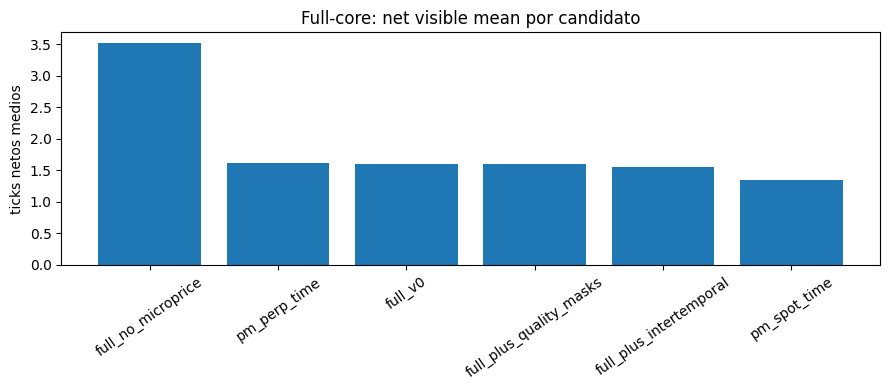

In [14]:
final_summary = read_csv(FULL_RESULTS / 'final_summary.csv')
cols = [
    'model_kind', 'feature_set', 'selected_threshold',
    'test_balanced_accuracy', 'test_macro_f1',
    'test_action_actions', 'test_action_coverage_pct',
    'test_action_hit_up_pct', 'test_action_wrong_down_pct',
    'test_action_net_visible_mean', 'test_action_net_positive_pct'
]
display(final_summary[cols].round(4))

plot_df = final_summary.head(7).copy()
fig, ax = plt.subplots(figsize=(9, 4))
labels = plot_df['feature_set']
ax.bar(labels, plot_df['test_action_net_visible_mean'])
ax.set_title('Full-core: net visible mean por candidato')
ax.set_ylabel('ticks netos medios')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


### Lectura del full-core

Lo que aprendi aqui:

- PM solo no basta: muchas acciones, pero neto negativo.
- `time_only` tampoco basta: el reloj no explica el edge por si solo.
- `pm_perp_time` es muy fuerte: PM + perp es el bloque clave.
- `full_v0` queda como baseline general.
- `full_no_microprice` queda como filtro de alta conviccion: menos acciones, mas calidad.

Esto fue un `GO` para una iteracion v0.1 offline, no para bot.

## 11. Sanity check: era solo el reloj?

Como la importancia del tiempo salia alta, hicimos una prueba importante: entrenar modelos con `time_only`.

Si `time_only` fuera bueno, el modelo podria estar aprovechando un patron temporal tonto. Pero salio neto negativo.

,feature_set,folds,mean_balanced_accuracy,mean_actions,mean_coverage_pct,mean_hit_up_pct,mean_wrong_down_pct,mean_net_visible_mean,min_net_visible_mean,mean_net_positive_pct
0,full_no_microprice,4,0.5880,"2,418.2500",1.4430,75.1606,13.4102,4.3793,3.4731,75.1164
1,perp_time_only,4,0.5535,"2,296.2500",1.3655,68.3727,19.3504,3.7128,3.0519,69.0127
2,pm_perp_time,4,0.6050,"2,572.5000",1.5531,72.9545,12.5200,3.2196,2.4557,73.2106
3,spot_time_only,4,0.5454,"2,679.0000",1.6061,64.8979,20.2688,2.9798,2.5692,65.7672
4,time_only,4,0.5036,"167,514.5000",99.9691,26.3133,26.8055,-0.7451,-0.8052,27.3273


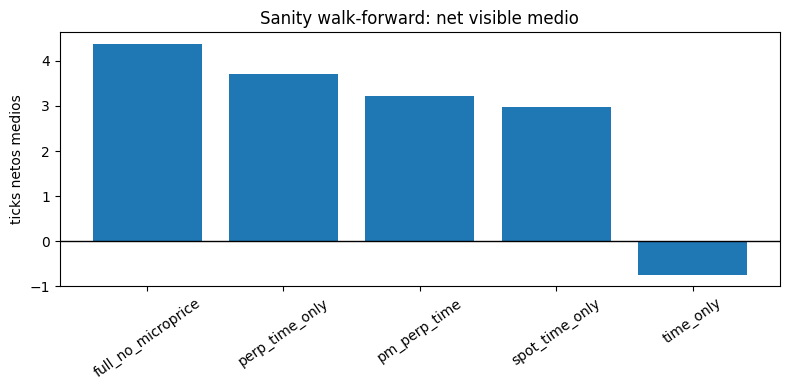

In [15]:
sanity = read_csv(FULL_RESULTS / 'feature_sanity_summary.csv')
display(sanity.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sanity['feature_set'], sanity['mean_net_visible_mean'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Sanity walk-forward: net visible medio')
ax.set_ylabel('ticks netos medios')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


## 12. v0.1: threshold elegido por folds + bootstrap

En v0.1 hicimos algo m?s serio:

- no elegir threshold mirando test;
- elegir threshold con folds anteriores;
- aplicar ese threshold al test terminal;
- calcular intervalos bootstrap;
- mirar acciones no solapadas H16.

El threshold elegido fue `0.55` para los tres candidatos.

In [16]:
threshold_choices = read_csv(V01_RESULTS / 'fold_threshold_choices.csv')
display(threshold_choices[[
    'model_kind','feature_set','threshold','mean_actions','min_actions',
    'mean_hit_up_pct','mean_wrong_down_pct','mean_net_visible_mean','min_net_visible_mean','robust_score'
]].round(4))


,model_kind,feature_set,threshold,mean_actions,min_actions,mean_hit_up_pct,mean_wrong_down_pct,mean_net_visible_mean,min_net_visible_mean,robust_score
0,hgb_balanced_small,full_v0,0.5500,"2,183.0000",1545,74.4103,12.4548,3.3322,2.5184,3.5933
1,hgb_balanced_small,full_no_microprice,0.5500,"1,363.7500",1069,77.5192,12.5247,5.2584,4.5321,5.9184
2,hgb_balanced_small,pm_perp_time,0.5500,"2,053.5000",1422,74.3525,12.1263,3.4152,2.4557,3.6699


In [17]:
v01_test = read_csv(V01_RESULTS / 'test_summary_fold_thresholds.csv')
cols = [
    'label','threshold','actions','coverage_pct','hit_up_pct','hit_up_pct_ci_low','hit_up_pct_ci_high',
    'wrong_down_pct','wrong_down_pct_ci_low','wrong_down_pct_ci_high',
    'net_visible_mean','net_visible_mean_ci_low','net_visible_mean_ci_high',
    'nonoverlap_actions','nonoverlap_hit_up_pct','nonoverlap_wrong_down_pct','nonoverlap_net_visible_mean'
]
display(v01_test[cols].round(4))


,label,threshold,actions,coverage_pct,hit_up_pct,hit_up_pct_ci_low,hit_up_pct_ci_high,wrong_down_pct,wrong_down_pct_ci_low,wrong_down_pct_ci_high,net_visible_mean,net_visible_mean_ci_low,net_visible_mean_ci_high,nonoverlap_actions,nonoverlap_hit_up_pct,nonoverlap_wrong_down_pct,nonoverlap_net_visible_mean
0,hgb_balanced_small__full_no_microprice,0.5500,605,0.2771,83.3058,80.4959,86.1198,7.4380,5.4545,9.5868,5.1499,4.4943,5.7711,572,83.0420,7.6923,5.1100
1,hgb_balanced_small__full_v0,0.5500,1438,0.6586,74.1307,71.9037,76.3561,9.7357,8.2058,11.3369,2.3415,2.0620,2.6180,1150,74.7826,9.9130,2.5602
2,hgb_balanced_small__pm_perp_time,0.5500,1472,0.6741,73.5734,71.3315,75.8152,9.9185,8.4239,11.4147,2.3018,2.0382,2.5901,1173,74.9361,10.1449,2.5379


### Lectura v0.1

La parte importante es que el resultado aguanta incluso siendo m?s estrictos.

`full_v0`:

- m?s acciones;
- mejor como baseline general;
- `74.13%` hit up;
- `2.34` ticks netos medios.

`full_no_microprice`:

- menos acciones;
- mas selectivo;
- `83.31%` hit up;
- `5.15` ticks netos medios.

Mi conclusion: no hay que elegir uno y tirar el otro. `full_v0` es la base y `full_no_microprice` puede ser un overlay de alta conviccion.

## 13. Score: no basta con top decile

Tambien miramos deciles de score. Esto sirve para entender si el modelo mejora de forma gradual o solo en una cola muy extrema.

La conclusion fue: el top decile ya mejora, pero el threshold `0.55` selecciona una cola mucho mas estricta que el top decile. Por eso la calidad sube tanto.

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ftpx\AppData\Local\Temp\ipykernel_28196\1351410822.py:11: SyntaxWarning: invalid escape sequence '\d'
  part['decile_num'] = part['score_decile'].str.extract('(\d+)').astype(int)


,label,score_decile,actions,hit_up_pct,wrong_down_pct,net_visible_mean,net_positive_pct,score_min,score_max
7,hgb_balanced_small__full_v0,d8,21836,44.2709,23.0491,0.0078,45.3746,0.2203,0.2813
8,hgb_balanced_small__full_v0,d9,21835,49.3016,20.3984,0.2750,50.5244,0.2813,0.3635
9,hgb_balanced_small__full_v0,d10,21836,56.6816,15.5065,0.8179,57.8632,0.3635,0.7590
17,hgb_balanced_small__full_no_microprice,d8,21836,42.4666,29.0529,-0.3651,43.2909,0.1306,0.1909
18,hgb_balanced_small__full_no_microprice,d9,21835,47.1170,26.2377,-0.0167,47.9047,0.1909,0.2772
19,hgb_balanced_small__full_no_microprice,d10,21836,55.5093,20.0953,0.7750,56.4984,0.2772,0.7221
27,hgb_balanced_small__pm_perp_time,d8,21836,44.5961,23.0537,0.0738,45.8600,0.2200,0.2809
28,hgb_balanced_small__pm_perp_time,d9,21835,49.0405,20.7602,0.2390,50.2908,0.2809,0.3627
29,hgb_balanced_small__pm_perp_time,d10,21836,56.2466,15.4699,0.7909,57.4235,0.3627,0.7559


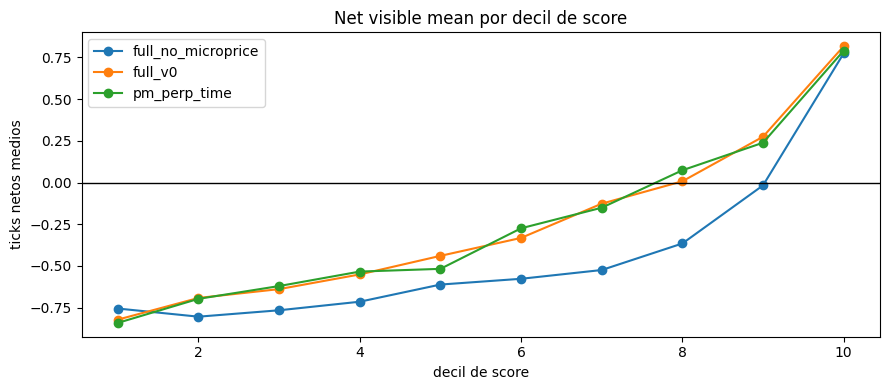

In [18]:
deciles = read_csv(V01_RESULTS / 'score_deciles.csv')
# Mostramos solo deciles altos para no llenar la libreta.
high_deciles = deciles[deciles['score_decile'].isin(['d8','d9','d10'])].copy()
display(high_deciles[[
    'label','score_decile','actions','hit_up_pct','wrong_down_pct','net_visible_mean','net_positive_pct','score_min','score_max'
]].round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for label, part in deciles.groupby('label'):
    part = part.copy()
    part['decile_num'] = part['score_decile'].str.extract('(\d+)').astype(int)
    ax.plot(part['decile_num'], part['net_visible_mean'], marker='o', label=label.replace('hgb_balanced_small__',''))
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Net visible mean por decil de score')
ax.set_xlabel('decil de score')
ax.set_ylabel('ticks netos medios')
ax.legend()
plt.tight_layout()
plt.show()


## 14. v0.2: backtest conservador offline

Aqui ya no entrenamos un modelo nuevo. Cogemos las acciones que v0.1 habia seleccionado con threshold elegido en folds y hacemos una prueba mas cercana a una decision operativa.

Que se probo:

- coste visible de entrada;
- buffer extra de `0.5 ticks` en algunos escenarios;
- filtros de spread/coste/score;
- cooldown por mercado (`condition_id`);
- resultados por dia y por sesion.

Sigue siendo offline. No modela fill real, cola, latencia ni sizing.

,policy,signals,market_frames,condition_ids,median_score,median_cost,hit_up_pct,wrong_down_pct,net_visible_mean,net_visible_sum
0,dual_full_v0_plus_highconv,1650,1650,413,0.5752,0.6545,74.7879,9.8182,2.7455,"4,530.1159"
1,full_no_micro_highconv,605,605,266,0.5839,0.6918,83.3058,7.4380,5.1499,"3,115.6930"
2,full_v0_base,1438,1438,378,0.5777,0.6343,74.1307,9.7357,2.3415,"3,367.0304"
3,pm_perp_control,1472,1472,387,0.5794,0.6476,73.5734,9.9185,2.3018,"3,388.2059"


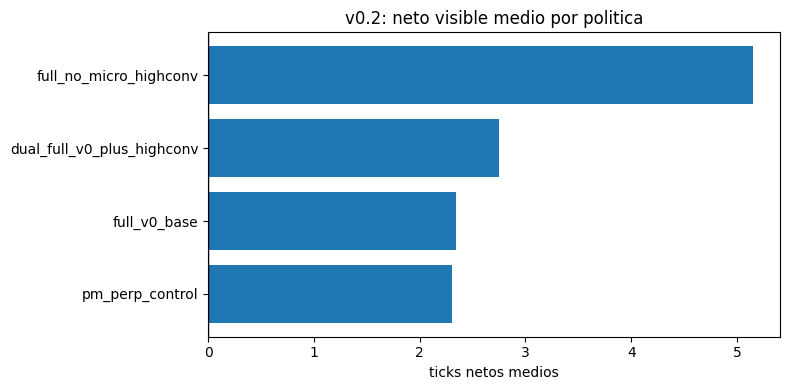

In [19]:
v02_policy = read_csv(V02_RESULTS / 'policy_signal_summary.csv')
policy_cols = [
    'policy', 'signals', 'market_frames', 'condition_ids', 'median_score', 'median_cost',
    'hit_up_pct', 'wrong_down_pct', 'net_visible_mean', 'net_visible_sum'
]
display(v02_policy[policy_cols].round(4))

plot_policy = v02_policy.sort_values('net_visible_mean', ascending=True).copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_policy['policy'], plot_policy['net_visible_mean'])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('v0.2: neto visible medio por politica')
ax.set_xlabel('ticks netos medios')
plt.tight_layout()
plt.show()

,scenario_id,actions,coverage_pct,hit_up_pct,wrong_down_pct,net_mean,net_sum,net_positive_pct,max_drawdown_ticks,positive_day_pct,positive_session_pct
0,full_no_micro_highconv__strict_score_cost_plus...,203,0.0930,88.6700,3.9409,5.9535,"1,208.5564",80.2956,-26.4743,100.0000,86.1789
1,full_no_micro_highconv__cross_visible__cooldow...,454,0.2079,84.1410,7.7093,5.4560,"2,477.0034",84.1410,-25.4743,100.0000,87.0968
2,full_no_micro_highconv__cross_visible__cooldow...,605,0.2771,83.3058,7.4380,5.1499,"3,115.6930",83.3058,-25.4743,100.0000,88.7097
3,full_no_micro_highconv__cross_visible__cooldow...,504,0.2308,83.9286,7.7381,5.2166,"2,629.1812",83.9286,-25.4743,100.0000,86.6935
4,full_no_micro_highconv__cross_visible__cooldow...,572,0.2620,83.0420,7.6923,5.1100,"2,922.8998",83.2168,-25.4743,100.0000,87.5000
5,full_no_micro_highconv__low_spread_plus_0p5tic...,431,0.1974,84.9188,6.9606,5.1265,"2,209.5259",75.6381,-26.4743,100.0000,79.6680
6,full_no_micro_highconv__low_cost_plus_0p5tick_...,431,0.1974,84.9188,6.9606,5.1265,"2,209.5259",75.6381,-26.4743,100.0000,79.6680
7,full_no_micro_highconv__cross_plus_0p5tick__co...,454,0.2079,84.1410,7.7093,4.9560,"2,250.0034",74.8899,-26.4743,100.0000,79.4355
8,full_no_micro_highconv__low_spread_plus_0p5tic...,477,0.2185,84.4864,7.1279,4.8456,"2,311.3610",74.8428,-26.4743,100.0000,79.2531
9,full_no_micro_highconv__low_cost_plus_0p5tick_...,477,0.2185,84.4864,7.1279,4.8456,"2,311.3610",74.8428,-26.4743,100.0000,79.2531


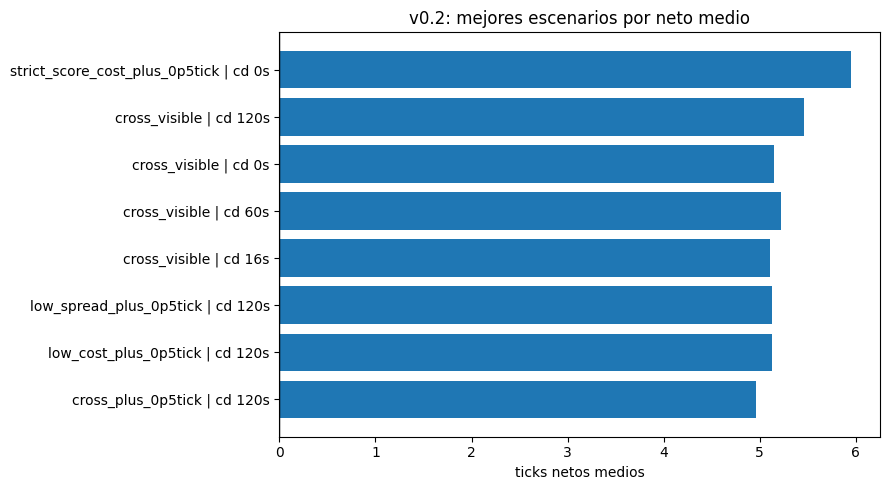

In [20]:
v02_reco = read_csv(V02_RESULTS / 'recommended_scenarios.csv')
scenario_cols = [
    'scenario_id', 'actions', 'coverage_pct', 'hit_up_pct', 'wrong_down_pct',
    'net_mean', 'net_sum', 'net_positive_pct', 'max_drawdown_ticks',
    'positive_day_pct', 'positive_session_pct'
]
display(v02_reco[scenario_cols].head(10).round(4))

plot_scenarios = v02_reco.head(8).copy()
plot_scenarios['scenario_short'] = plot_scenarios['scenario_id'].str.replace('full_no_micro_highconv__', '', regex=False)
plot_scenarios['scenario_short'] = plot_scenarios['scenario_short'].str.replace('__cooldown_', ' | cd ', regex=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_scenarios['scenario_short'][::-1], plot_scenarios['net_mean'][::-1])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('v0.2: mejores escenarios por neto medio')
ax.set_xlabel('ticks netos medios')
plt.tight_layout()
plt.show()

### Lectura v0.2

La lectura importante es sencilla:

- `full_no_micro_highconv` sigue siendo la politica mas limpia;
- el escenario strict tiene pocas acciones (`203`) pero mucha calidad: `88.67%` hit up y solo `3.94%` wrong down;
- la version `cross_visible` sin cooldown tiene mas acciones (`605`) y mas neto total proxy;
- los cooldowns no rompen la senal, asi que no parece depender solo de repetir muchas veces el mismo instante;
- `dual_full_v0_plus_highconv` suma acciones, pero baja calidad y aumenta riesgo.

Mi decision: usar `full_no_micro_highconv` como politica conservadora candidata para la siguiente fase, no como bot.

,session_day,actions,hit_up_pct,wrong_down_pct,net_mean,net_sum,max_drawdown_ticks
108,2026-05-23,85,88.2353,5.8824,5.3667,456.1693,-14.5045
109,2026-05-24,70,85.7143,0.0000,6.9824,488.7647,-2.2476
110,2026-05-25,48,93.7500,6.2500,5.4921,263.6223,-26.4743


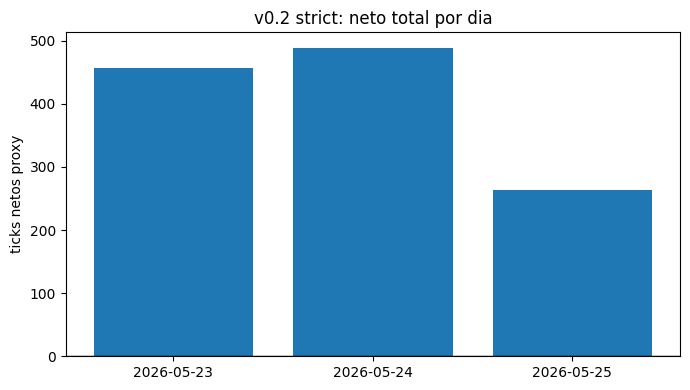

In [21]:
strict_id = 'full_no_micro_highconv__strict_score_cost_plus_0p5tick__cooldown_0s'
v02_daily = read_csv(V02_RESULTS / 'daily_summary.csv')
strict_daily = v02_daily[v02_daily['scenario_id'].eq(strict_id)].copy()

daily_cols = ['session_day', 'actions', 'hit_up_pct', 'wrong_down_pct', 'net_mean', 'net_sum', 'max_drawdown_ticks']
display(strict_daily[daily_cols].round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(strict_daily['session_day'], strict_daily['net_sum'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('v0.2 strict: neto total por dia')
ax.set_ylabel('ticks netos proxy')
plt.tight_layout()
plt.show()

## 15. Estado actual del proyecto

Decision actual:

```text
GO para consolidacion v0.3 offline
NO GO para bot
NO GO para modelos complejos todavia
```

Por que si seguir:

- hay senal fuera de muestra;
- aguanta full-core;
- aguanta folds;
- aguanta bootstrap;
- aguanta no-solapado H16;
- aguanta un backtest conservador simple;
- PM + perp aparece varias veces como bloque importante.

Por que no bot todavia:

- no hemos simulado fills reales;
- no hay latencia;
- no hay sizing;
- no hay control de liquidez real por frame;
- solo tenemos tres dias de test terminal;
- no sabemos si se puede ejecutar todo lo que el modelo marca.

## 16. Siguiente paso: v0.3 offline

Lo siguiente no deberia ser un modelo complejo. Antes hay que ordenar el terreno.

Plan v0.3:

1. consolidar un dataset de modelado reproducible;
2. dejar fijo el contrato de features v0.3;
3. anadir diagnosticos por `temporality`, fase de ventana y coste;
4. mantener `full_no_micro_highconv` como politica conservadora candidata;
5. comparar cualquier feature nueva contra este baseline;
6. documentar exactamente que cambia y que mejora.

Esto es importante porque una cosa es encontrar edge offline y otra distinta es construir una estrategia ejecutable.

## 17. Como explicarlo al profesor

Una forma sencilla de defenderlo seria:

> Primero valide la calidad del corpus y elegi un target causal a 16 segundos. Despues comprobe que las senales de Polymarket y del perp tenian relacion con el movimiento futuro. Para evitar leakage hice splits temporales y evalue por market-frame, no por token aislado. Luego entrene baselines tabulares sencillos. El resultado muestra edge offline, especialmente cuando el score es alto. En v0.2 meti coste visible, buffer y cooldowns simples. La senal aguanta, pero todavia no lo considero estrategia real porque falta modelar ejecucion, fills, latencia y sizing.

Puntos que conviene decir claramente:

- no estamos prometiendo bot;
- el resultado es offline;
- el split es temporal;
- el test terminal no se usa para elegir threshold;
- el edge se reduce a pocas acciones de alta conviccion;
- la siguiente fase es consolidar dataset/modelado, no saltar a redes ni bot.

## 18. Archivos importantes

| Archivo | Uso |
|---|---|
| `docs/BASELINE_CONTRACT_V0.md` | contrato del baseline |
| `docs/BASELINE_V0_FULL_CORE_ROBUSTNESS.md` | ejecucion grande full-core |
| `docs/BASELINE_V01_THRESHOLD_BOOTSTRAP.md` | threshold por folds + bootstrap |
| `docs/BASELINE_V02_CONSERVATIVE_BACKTEST.md` | backtest conservador v0.2 |
| `notebooks/12_baseline_v0_full_core_robustness.ipynb` | notebook de robustness |
| `notebooks/14_baseline_v01_threshold_bootstrap.ipynb` | notebook v0.1 |
| `notebooks/15_baseline_v02_conservative_backtest.ipynb` | notebook v0.2 |
| `data/experiments/baseline_v02_conservative_backtest/` | CSV/JSON con resultados v0.2 |

Este notebook es la version unificada para leer y presentar.